# Difficulty Based Analysis

## Dataset Creation

Create Dataset consolidated from RAVEN100 or any other folder along with weighted score for difficulty

In [ ]:
# Basic Imports for the dataset analysis
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import xml.etree.ElementTree as ET

In [ ]:

# Import all Files by Folder From RAVEN-1000
# COlumns
### Name, Structure, Component, Layout, Rule_Group_0_Number,Rule_Group_0_Position, Rule_Group_0_Type, Rule_Group_0_Size, Rule_Group_0_Color,
### Rule_Group_1_Number,Rule_Group_1_Position, Rule_Group_1_Type, Rule_Group_1_Size, Rule_Group_1_Color```
dataset_summary = pd.DataFrame(columns=['File_Name', 'Folder', 'Type', 'Structure', 
'Layout_0', 
'Layout_1', 
'No_of_Rule_Groups',
'Rule_Group_0_Number', 
'Rule_Group_0_Position', 
'Rule_Group_0_Type', 
'Rule_Group_0_Size',  
'Rule_Group_0_Color', 
'Rule_Group_1_Number', 
'Rule_Group_1_Position', 
'Rule_Group_1_Type', 
'Rule_Group_1_Size', 
'Rule_Group_1_Color',
'No_of_Rules'])

# directory = "RAVEN-10000/center_single"

# The list of directories to be analyzed
directory_details = [
{
    "directory": "RAVEN-10000/center_single",
    "folder": "center_single",
    "structure": "Singleton",
    "layout_0": "Center_Single",
    "layout_1": np.nan,
    
},
{
    "directory": "RAVEN-10000/distribute_four",
    "folder": "distribute_four",
    "structure": "Singleton",
    "layout_0": "Distribute_Four",
    "layout_1": np.nan,
    
},
{
    "directory": "RAVEN-10000/distribute_nine",
    "folder": "distribute_nine",
    "structure": "Singleton",
    "layout_0": "Distribute_Nine",
    "layout_1": np.nan,
    
},
{
    "directory": "RAVEN-10000/in_center_single_out_center_single",
    "folder": "in_center_single_out_center_single",
    "structure": "Out_In",
    "layout_0": "Out_Center_Single",
    "layout_1": "In_Center_Single",
    
},
{
    "directory": "RAVEN-10000/in_distribute_four_out_center_single/",
    "folder": "in_distribute_four_out_center_single",
    "structure": "Out_In",
    "layout_0": "Out_Center_Single",
    "layout_1": "In_Distribute_Four",
    
},
{
    "directory": "RAVEN-10000/left_center_single_right_center_single",
    "folder": "left_center_single_right_center_single",
    "structure": "Left_Right",
    "layout_0": "Left_Center_Single",
    "layout_1": "Right_Center_Single",
    
},
{
    "directory": "RAVEN-10000/up_center_single_down_center_single",
    "folder": "up_center_single_down_center_single",
    "structure": "Up_Down",
    "layout_0": "Up_Center_Single",
    "layout_1": "Down_Center_Single",
    
}
]


In [ ]:
### Run this code to create the dataset summary with the weighthed score
for directory_detail in directory_details:
    # print("0000")
    folder = Path(directory_detail["directory"])
    for xml_file in sorted(folder.glob("*.xml"), key=lambda f: int(f.name.split('_')[1])):
        # i+=1
        # if i > 4:
        #     break
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        file_name = xml_file.name
        # train/test or val
        suffix = xml_file.stem.rsplit('_', 1)[-1]

        rules_elem = root.find("Rules")
        rule_group_0_number = np.nan
        rule_group_0_position = np.nan
        rule_group_0_size = np.nan
        rule_group_0_type = np.nan
        rule_group_0_color = np.nan

        rule_group_1_number = np.nan
        rule_group_1_position = np.nan
        rule_group_1_size = np.nan
        rule_group_1_type = np.nan
        rule_group_1_color = np.nan
        if rules_elem is not None:
            # sort Rule_Group by numeric id
            # print('-00ddd')
            groups = sorted(
                rules_elem.findall("Rule_Group"),
                key=lambda g: int(g.get("id"))
            )
        

            num_of_rule_groups = 1
            num_of_rules=0
            for g in groups:
                # print("---groups")
                group_id = int(g.get("id"))
                if group_id == 0:
                    for r in g.findall("Rule"):
                        # print( r.get("attr"))
                        if r.get("attr") == 'Number':
                            # print('dsdsd')
                            rule_group_0_number = r.get("name")
                        elif r.get("attr") == 'Position':
                            rule_group_0_position = r.get("name")
                        elif r.get("attr") == 'Type':
                            rule_group_0_type = r.get("name")
                        elif r.get("attr") == 'Size':
                            rule_group_0_size = r.get("name")
                        elif r.get("attr") == 'Color':
                            rule_group_0_color = r.get("name")
                        elif r.get("attr") == 'Number/Position':
                            # print("sdsd")
                            rule_group_0_number = r.get("name")
                            rule_group_0_position = r.get("name")
                            
                        if r.get("attr") != 'Number/Position' and r.get("name") != 'Constant':
                            num_of_rules+=1
                        elif  r.get("attr") == 'Number/Position' and r.get("name") != 'Constant':
                            num_of_rules+=2

                            
                elif group_id == 1:
                        # print(r.get("attr"), r.get("name"))
                    num_of_rule_groups = 2
                    for r in g.findall("Rule"):
                        if r.get("attr") == 'Number':
                            rule_group_1_number = r.get("name")
                        elif r.get("attr") == 'Position':
                            rule_group_1_position = r.get("name")
                        elif r.get("attr") == 'Type':
                            rule_group_1_type = r.get("name")
                        elif r.get("attr") == 'Size':
                            rule_group_1_size = r.get("name")
                        elif r.get("attr") == 'Color':
                            rule_group_1_color = r.get("name")
                        elif r.get("attr") == 'Number/Position':
                            rule_group_1_number = r.get("name")
                            rule_group_1_position = r.get("name")

                        if r.get("attr") != 'Number/Position' and r.get("name") != 'Constant':
                            num_of_rules+=1
                        elif  r.get("attr") == 'Number/Position' and r.get("name") != 'Constant':
                            num_of_rules+=2
                

        dataset_summary.loc[len(dataset_summary)] = {
            "File_Name": file_name,
            "Folder": directory_detail["folder"],
            "Type": suffix,
            "Structure": directory_detail["structure"],
            "Layout_0": directory_detail["layout_0"],
            "Layout_1": directory_detail["layout_1"],
            "No_of_Rule_Groups":num_of_rule_groups,
            "Rule_Group_0_Number": rule_group_0_number, 
            "Rule_Group_0_Position":rule_group_0_position, 
            "Rule_Group_0_Type": rule_group_0_type,  
            "Rule_Group_0_Size": rule_group_0_size,  
            "Rule_Group_0_Color": rule_group_0_color, 
            "Rule_Group_1_Number": rule_group_1_number, 
            "Rule_Group_1_Position": rule_group_1_position,  
            "Rule_Group_1_Type": rule_group_1_type, 
            "Rule_Group_1_Size": rule_group_1_size, 
            "Rule_Group_1_Color":rule_group_1_color,
            "No_of_Rules":num_of_rules

        }
    # rules_elem = root.find()

rule_columns = [
    'Rule_Group_0_Number', 'Rule_Group_0_Position', 'Rule_Group_0_Type', 
    'Rule_Group_0_Size', 'Rule_Group_0_Color',
    'Rule_Group_1_Number', 'Rule_Group_1_Position', 'Rule_Group_1_Type', 
    'Rule_Group_1_Size', 'Rule_Group_1_Color'
]

# analysis_pd['Total'] = analysis_pd['Column_A'].fillna(0) + analysis_pd['Column_B'].fillna(0)
dataset_summary['No_of_Constant'] = (dataset_summary[rule_columns] == 'Constant').sum(axis=1)
dataset_summary['No_of_Progression'] = (dataset_summary[rule_columns] == 'Progression').sum(axis=1)
dataset_summary['No_of_Arithmetic'] = (dataset_summary[rule_columns] == 'Arithmetic').sum(axis=1)
dataset_summary['No_of_Distribute_Three'] = (dataset_summary[rule_columns] == 'Distribute_Three').sum(axis=1)


# dataset_summary['Weighted_Score'] = (1*dataset_summary['No_of_Constant'])+(2*dataset_summary['No_of_Progression'])+(3*dataset_summary['No_of_Arithmetic'])+(4*dataset_summary['No_of_Distribute_Three'])
# Weighted Score
dataset_summary['Weighted_Score'] = (1*dataset_summary['No_of_Constant'])+(2*dataset_summary['No_of_Progression'])+(3*dataset_summary['No_of_Arithmetic'])+(4*dataset_summary['No_of_Distribute_Three'])

dataset_summary.to_csv('dataset_summary_final_score.csv', index=False)

## Analysis & Binnning

Undestand thresholds for low medium and high difficulty

In [ ]:

# Understanding Tertlies of how we can bin the score based on difficulty
analysis_pd = pd.read_csv('dataset_summary_final_score.csv')
q1 = analysis_pd["Weighted_Score"].quantile(1/3)
q2 = analysis_pd["Weighted_Score"].quantile(2/3)

print("1/3 threshold:", q1)
print("2/3 threshold:", q2)

1/3 threshold: 12.0
2/3 threshold: 17.0


In [ ]:
# Analyze the counst

low_count = (analysis_pd['Weighted_Score'] < 12).sum()
medium_count = ((analysis_pd['Weighted_Score'] >= 12) & (analysis_pd['Weighted_Score'] <= 17)).sum()
high_count = (analysis_pd['Weighted_Score'] > 17).sum()
# print(f"Number of records with Weighted_Score  12: {count}")
print("Counts", low_count, medium_count, high_count, low_count+medium_count+high_count)
print("Counts", low_count/70000, medium_count/70000, high_count/70000, low_count+medium_count+high_count)



Counts 23101 23673 23226 70000
Counts 0.3300142857142857 0.3381857142857143 0.3318 70000


In [ ]:

# count = ((analysis_pd['Weighted_Score'] == 12) | (analysis_pd['Weighted_Score'] == 13) | (analysis_pd['Weighted_Score'] == 14)
# | (analysis_pd['Weighted_Score'] == 15)
# | (analysis_pd['Weighted_Score'] == 16) | (analysis_pd['Weighted_Score'] == 17)).sum()
# print(f"Number of records with Weighted_Score  12: {count}")

Number of records with Weighted_Score  12: 26763


In [ ]:
analysis_pd = pd.read_csv('dataset_summary_final_score.csv')
conditions = [
    analysis_pd['Weighted_Score'] < 12,
    (analysis_pd['Weighted_Score'] >= 12) & (analysis_pd['Weighted_Score'] <= 17),
    analysis_pd['Weighted_Score'] > 17
]
choices = np.array(['low', 'medium', 'high'], dtype=object)

analysis_pd['difficulty'] = np.select(conditions, choices, default='high')
# analysis_pd.to_csv('dataset_summary_final_score.csv', index=False)


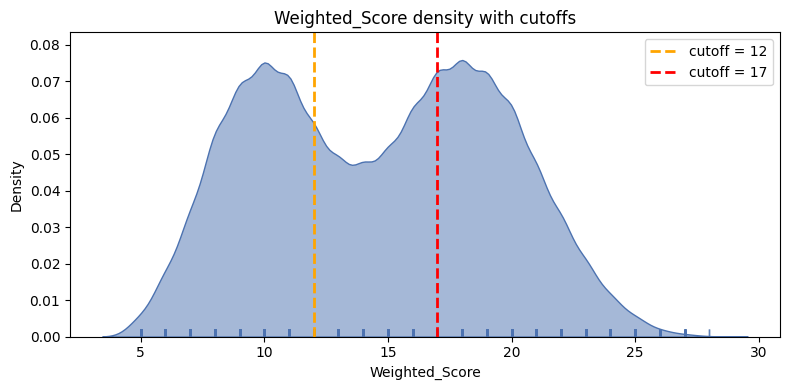

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

scores = analysis_pd['Weighted_Score']

plt.figure(figsize=(8,4))
sns.histplot(scores, bins=30, color='#4c72b0', alpha=0.6, kde=True)

# Add cutoff lines
plt.axvline(12, color='orange', linestyle='--', linewidth=2, label='cutoff = 12')
plt.axvline(17, color='red', linestyle='--', linewidth=2, label='cutoff = 17')

plt.xlabel('Weighted_Score')
plt.ylabel('Count')
plt.title('Weighted_Score distribution with cutoffs')
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
analysis_pd = pd.read_csv('dataset_summary_final_score.csv')
analysis_pd['difficulty'].value_counts()
# Counts 23101 23673 23226 70000
# Counts 0.3300142857142857 0.3381857142857143 0.3318 70000

difficulty
medium    23673
high      23226
low       23101
Name: count, dtype: int64

In [18]:
import pandas as pd


pd_low = pd.read_csv('evaluation_results_low.csv')
pd_medium = pd.read_csv('evaluation_results_medium.csv')
pd_high =  pd.read_csv('evaluation_results_high.csv')

## Splitting
Data set is split in low, medium and difficult in different folders for running the model evaluation

In [100]:
import pandas as pd
dataset_detail = pd.read_csv('dataset_summary_final_score.csv')

In [101]:
from pathlib import Path
import shutil
#  Create a folder
FOLDER_NAME = 'Testing_Data'
DATA_DIRECTORY = 'RAVEN-10000'
Path(FOLDER_NAME).mkdir(parents=True, exist_ok=True)

difficulty_levels = ['low', 'medium', 'high']
for difficulty in difficulty_levels:
    # current_data = dataset_detail[dataset_detail['difficulty'] == difficulty] 
    # current_data = dataset_detail[(dataset_detail['Type'] == 'test') && (dataset_detail['difficulty'] == difficulty)]
    # current_data['file_path'] = DATA_DIRECTORY+'/'+current_data['folder']+ '/'+ current_data['File_Name']
    current_data = dataset_detail[(dataset_detail['Type'] == 'test') & (dataset_detail['difficulty'] == difficulty)]
    file_path_xml = DATA_DIRECTORY+'/'+current_data['Folder']+ '/'+ current_data['File_Name']

    dest_folder = Path(FOLDER_NAME) / difficulty
    dest_folder.mkdir(parents=True, exist_ok=True)

    # Iterate over each row in current_data
    for idx, row in current_data.iterrows():
        # Source file path
        file_path_xml = Path(DATA_DIRECTORY) / row['Folder'] / row['File_Name']
        file_name_npz = row['File_Name'].rsplit('.xml', 1)[0] + '.npz'
        file_path_npz =  Path(DATA_DIRECTORY) / row['Folder'] / file_name_npz
        # me
        new_file_path_xml = row['Folder']+ '_'+ row['File_Name']
        new_file_name_npz =  row['Folder']+ '_'+ file_name_npz

        dest_path_xml =  dest_folder / new_file_path_xml
        dest_path_npz =  dest_folder / new_file_name_npz
        # Destination path
        # dest_path = dest_folder / new_filename
        
        # Copy the file
        if file_path_xml.exists():
            shutil.copy2(file_path_xml, dest_path_xml)
            # print()
        else:
            print(f"Warning: File not found: {file_path_xml}")

        if file_path_npz.exists():
            shutil.copy2(file_path_npz, dest_path_npz)
            # print()
        else:
            print(f"Warning: File not found: {file_path_xml}")
    



In [102]:
# Sanity Check

from pathlib import Path
# DATA_DIRECTORY = 'RAVEN-10000'
FOLDER_NAME = 'Testing_Data'
difficulty_levels = ['low', 'medium', 'high'] 
for i in range(len(difficulty_levels)):
    dest_folder = Path(FOLDER_NAME) / difficulty_levels[i]
    # directory = Path(DATA_DIRECTORY)
    # current_data = dataset_detail[dataset_detail['difficulty'] == difficulty_levels[i]]
    current_data = dataset_detail[  (dataset_detail['Type'] == 'test') & (dataset_detail['difficulty'] == difficulty_levels[i])]
   
    # Count all files (not directories)
    file_count = sum(1 for item in dest_folder.iterdir() if item.is_file())
    print(f"Number of files: {file_count} , length--> {len(current_data)*2}")

Number of files: 9266 , length--> 9266
Number of files: 9350 , length--> 9350
Number of files: 9384 , length--> 9384


In [51]:
import numpy as np
import zipfile

def is_valid_npz(filepath):
    """
    Checks if an .npz file is valid by attempting to load it.

    Args:
        filepath (str): The path to the .npz file.

    Returns:
        bool: True if the file is a valid .npz file, False otherwise.
    """
    try:
        with np.load(filepath) as data:
            # Optionally, you can perform further checks here,
            # such as verifying the presence of expected arrays:
            # if 'my_array_key' not in data.files:
            #     return False
            pass # If loading succeeds, the file is likely valid
        return True
    except FileNotFoundError:
        print(f"Error: File not found at '{filepath}'")
        return False
    except zipfile.BadZipFile:
        print(f"Error: '{filepath}' is not a valid zip file (corrupted or not an NPZ).")
        return False
    except Exception as e:
        print(f"An unexpected error occurred while loading '{filepath}': {e}")
        return False

# Example usage:
if is_valid_npz("Testing_Data/high/in_center_single_out_center_single_RAVEN_48_test.npz"):
    print("my_data.npz is a valid NPZ file.")
else:
    print("my_data.npz is NOT a valid NPZ file.")

my_data.npz is a valid NPZ file.


## Visualization

Visualization of results

In [144]:
import pandas as pd

pd_low = pd.read_csv('evaluation_results_low.csv')
pd_medium =  pd.read_csv('evaluation_results_medium.csv')
pd_high =  pd.read_csv('evaluation_results_high.csv')

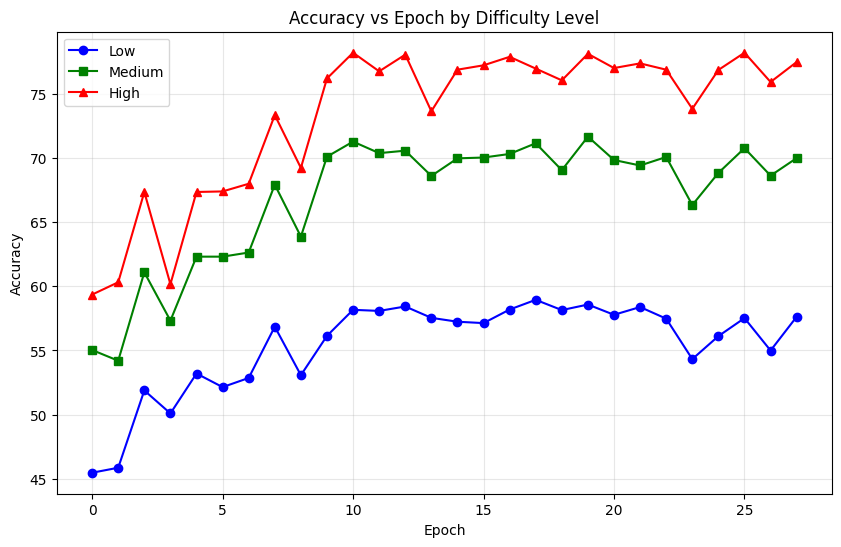

In [145]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plot each dataframe with different colors
plt.plot(pd_low['epoch'], pd_low['accuracy'], label='Low', color='blue', marker='o')
plt.plot(pd_medium['epoch'], pd_medium['accuracy'], label='Medium', color='green', marker='s')
plt.plot(pd_high['epoch'], pd_high['accuracy'], label='High', color='red', marker='^')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch by Difficulty Level')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

# Entity Rule Based Analysis (Ignore)

In [ ]:
import pandas as pd
dataset_detail = pd.read_csv('dataset_summary_new_score.csv')
# dataset_detail['No_of_Progression'] = (dataset_detail[rule_columns] == 'Progression').sum(axis=1)
# dataset_detail['No_of_Arithmetic'] = (dataset_detail[rule_columns] == 'Arithmetic').sum(axis=1)
# dataset_detail['No_of_Distribute_Three'] = (dataset_detail[rule_columns] == 'Distribute_Three').sum(axis=1)
dataset_detail['total_rules'] =  dataset_detail['No_of_Progression'] +dataset_detail['No_of_Arithmetic']+dataset_detail['No_of_Distribute_Three'] 
# single_run = dataset_detail
dataset_detail = dataset_detail[dataset_detail['Type']== 'test']
# Total number with one Rule Change that is not a numersority change
single_rule_non_numerosity = dataset_detail[(dataset_detail['total_rules'] == 1) & (dataset_detail['Rule_Group_0_Number'] == 'Constant')]

# Numberesority_change
single_rule_numerosity = dataset_detail[(dataset_detail['Rule_Group_0_Number'] != 'Constant') & (dataset_detail['total_rules'] <= 2)]


# (dataset_detail['Rule_Group_0_Number'] != 'Constant')
# dataset_detail['Rule_Group_0_Number'].value_counts

In [85]:
sample = pd.read_csv('dataset_summary_new_score.csv')
train = len(sample[sample['Type']== 'train'])
test = len(sample[sample['Type']== 'test'])
val = len(sample[sample['Type']== 'val'])
train, test, val

(42000, 14000, 14000)

In [ ]:
# output = dataset_detail[dataset_detail["Rule_Group_0_Number"].isna()]
# output

,File_Name,Folder,Type,Structure,Layout_0,Layout_1,No_of_Rule_Groups,Rule_Group_0_Number,Rule_Group_0_Position,Rule_Group_0_Type,...,Rule_Group_1_Size,Rule_Group_1_Color,No_of_Rules,No_of_Constant,No_of_Progression,No_of_Arithmetic,No_of_Distribute_Three,Weighted_Score,difficulty,total_rules
10008,RAVEN_8_test.xml,distribute_four,test,Singleton,Distribute_Four,NaN,1,NaN,Distribute_Three,Constant,...,NaN,NaN,3,1,1,0,2,9,low,3
10018,RAVEN_18_test.xml,distribute_four,test,Singleton,Distribute_Four,NaN,1,NaN,Arithmetic,Progression,...,NaN,NaN,4,0,2,1,1,11,low,4
10028,RAVEN_28_test.xml,distribute_four,test,Singleton,Distribute_Four,NaN,1,NaN,Distribute_Three,Constant,...,NaN,NaN,3,1,0,1,2,11,low,3
10029,RAVEN_29_test.xml,distribute_four,test,Singleton,Distribute_Four,NaN,1,NaN,Arithmetic,Constant,...,NaN,NaN,1,3,0,1,0,7,low,1
10048,RAVEN_48_test.xml,distribute_four,test,Singleton,Distribute_Four,NaN,1,NaN,Progression,Distribute_Three,...,NaN,NaN,4,0,3,0,1,9,low,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29959,RAVEN_9959_test.xml,distribute_nine,test,Singleton,Distribute_Nine,NaN,1,NaN,Distribute_Three,Constant,...,NaN,NaN,2,2,1,0,1,7,low,2
29978,RAVEN_9978_test.xml,distribute_nine,test,Singleton,Distribute_Nine,NaN,1,NaN,Progression,Constant,...,NaN,NaN,2,2,1,0,1,7,low,2
29988,RAVEN_9988_test.xml,distribute_nine,test,Singleton,Distribute_Nine,NaN,1,NaN,Distribute_Three,Distribute_Three,...,NaN,NaN,3,1,0,1,2,11,low,3
29998,RAVEN_9998_test.xml,distribute_nine,test,Singleton,Distribute_Nine,NaN,1,NaN,Progression,Constant,...,NaN,NaN,3,1,1,1,1,10,low,3


In [75]:
# Number
# Type, Size, Color
# condition = (dataset_detail['Rule_Group_0_Color'] != 'Constant') |  (dataset_detail['Rule_Group_1_Color'] != 'Constant')
condition = (
    ((dataset_detail['Rule_Group_0_Number'] != 'Constant') &
     (~dataset_detail['Rule_Group_0_Number'].isna())) |
    ((dataset_detail['Rule_Group_1_Number'] != 'Constant') &
     (~dataset_detail['Rule_Group_1_Number'].isna()))
)

# condition = (
#     ((dataset_detail['Rule_Group_0_Number'] != 'Constant')) |
#     ((dataset_detail['Rule_Group_1_Number'] != 'Constant') &
#      (~dataset_detail['Rule_Group_1_Number'].isna()))
# )
rule_change = dataset_detail[condition]
inverse =  dataset_detail[~condition]
rule_change.to_csv('number.csv')
inverse.to_csv('non_number.csv')
len(rule_change), len(inverse), len(rule_change)+len(inverse)

(2514, 11486, 14000)

Number: (2514, 11486, 14000)
Position (2526, 11474, 14000)
Type: (11137, 2863, 14000)
Size: (11818, 2182, 14000)
Color: (11156, 2844, 14000)

In [72]:
11156*2

22312

In [101]:
# total_subset.to_csv('single_rule_subet.csv')
single_rule_non_numerosity.to_csv('single_rule_non_numerosity.csv')
single_rule_numerosity.to_csv('single_rule_numerosity.csv')

In [109]:
# numerosity_single_rule_change['total_rules'].value_counts()

len(single_rule_non_numerosity), len(single_rule_numerosity)
# 3121

(572, 637)

In [81]:
from pathlib import Path
import shutil
#  Create a folder
FOLDER_NAME = 'non_number'
DATA_DIRECTORY = 'RAVEN-10000'
Path(FOLDER_NAME).mkdir(parents=True, exist_ok=True)

# difficulty_levels = ['low', 'medium', 'high']
# for difficulty in difficulty_levels:
    # current_data = dataset_detail[dataset_detail['difficulty'] == difficulty] 
    # current_data = dataset_detail[(dataset_detail['Type'] == 'test') && (dataset_detail['difficulty'] == difficulty)]
    # current_data['file_path'] = DATA_DIRECTORY+'/'+current_data['folder']+ '/'+ current_data['File_Name']
# current_data = rule_change
current_data = inverse
file_path_xml = DATA_DIRECTORY+'/'+current_data['Folder']+ '/'+ current_data['File_Name']

dest_folder = Path(FOLDER_NAME) 
dest_folder.mkdir(parents=True, exist_ok=True)

# Iterate over each row in current_data
for idx, row in current_data.iterrows():
    # Source file path
    file_path_xml = Path(DATA_DIRECTORY) / row['Folder'] / row['File_Name']
    file_name_npz = row['File_Name'].rsplit('.xml', 1)[0] + '.npz'
    file_path_npz =  Path(DATA_DIRECTORY) / row['Folder'] / file_name_npz
    # me
    new_file_path_xml = row['Folder']+ '_'+ row['File_Name']
    new_file_name_npz =  row['Folder']+ '_'+ file_name_npz

    dest_path_xml =  dest_folder / new_file_path_xml
    dest_path_npz =  dest_folder / new_file_name_npz
    # Destination path
    # dest_path = dest_folder / new_filename
    
    # Copy the file
    if file_path_xml.exists():
        shutil.copy2(file_path_xml, dest_path_xml)
        # print()
    else:
        print(f"Warning: File not found: {file_path_xml}")

    if file_path_npz.exists():
        shutil.copy2(file_path_npz, dest_path_npz)
        # print()
    else:
        print(f"Warning: File not found: {file_path_xml}")
    



In [82]:
from pathlib import Path
# DATA_DIRECTORY = 'RAVEN-10000'
FOLDER_NAME = 'non_number'
dest_folder = Path(FOLDER_NAME) 
# directory = Path(DATA_DIRECTORY)
# current_data = dataset_detail[dataset_detail['difficulty'] == difficulty_levels[i]]
# current_data = dataset_detail[  (dataset_detail['Type'] == 'test') & (dataset_detail['difficulty'] == difficulty_levels[i])]
# current_data = current_data
# Count all files (not directories)
file_count = sum(1 for item in dest_folder.iterdir() if item.is_file())
print(f"Number of files: {file_count} , length--> {len(current_data)*2}")

Number of files: 22972 , length--> 22972


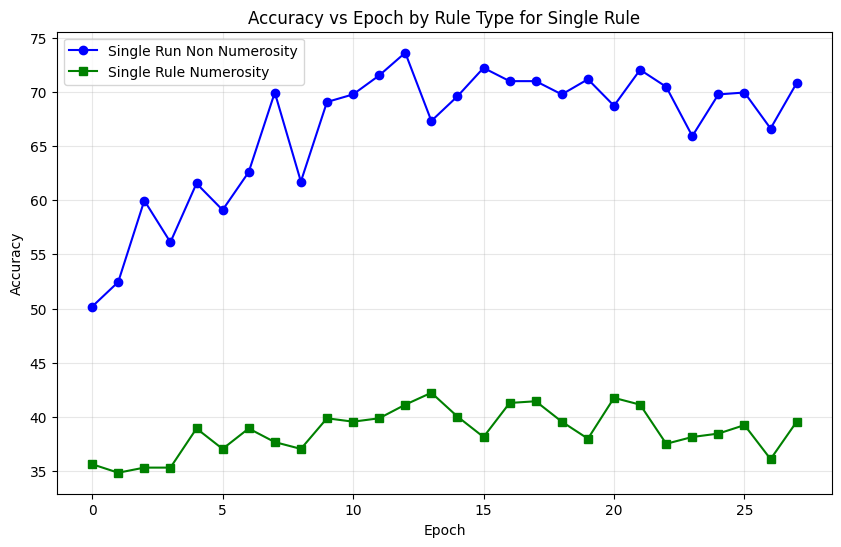

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

pd_non_numerosity = pd.read_csv('evaluation_results_single_rule_non_numerosity.csv')
pd_numerosity =  pd.read_csv('evaluation_results_single_rule_numerosity.csv')
# Create the plot
plt.figure(figsize=(10, 6))

# Plot each dataframe with different colors
plt.plot(pd_non_numerosity['epoch'], pd_non_numerosity['accuracy'], label='Single Run Non Numerosity', color='blue', marker='o')
plt.plot(pd_numerosity['epoch'], pd_numerosity['accuracy'], label='Single Rule Numerosity', color='green', marker='s')
# plt.plot(pd_high['epoch'], pd_high['accuracy'], label='High', color='red', marker='^')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch by Rule Type for Single Rule')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

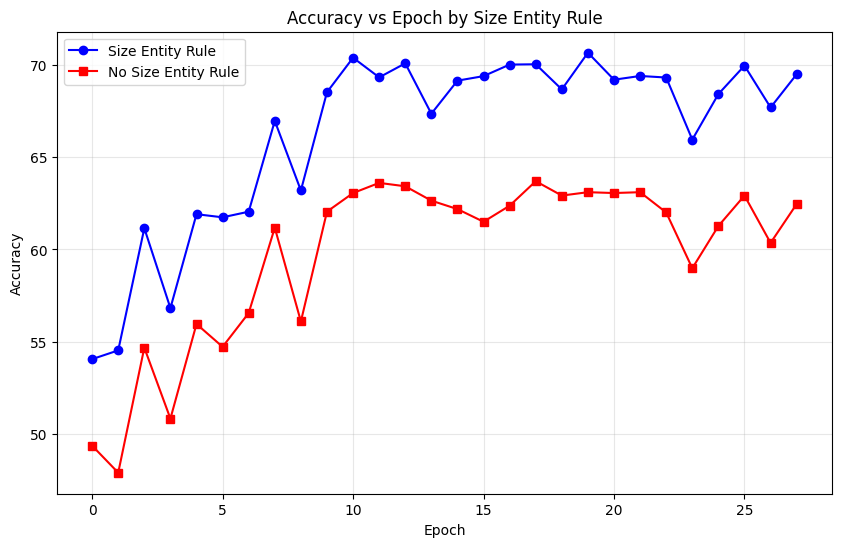

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

pd_number = pd.read_csv('evaluation_results_size.csv')
pd_non_number =  pd.read_csv('evaluation_results_non_size.csv')
# Create the plot
plt.figure(figsize=(10, 6))

# Plot each dataframe with different colors
plt.plot(pd_number['epoch'], pd_number['accuracy'], label='Size Attribute Rule', color='blue', marker='o')
plt.plot(pd_non_number['epoch'], pd_non_number['accuracy'], label='No Size Attribute Rule', color='red', marker='s')
# plt.plot(pd_high['epoch'], pd_high['accuracy'], label='High', color='red', marker='^')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch by Size Attribute Rule')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# pd_number = pd.read_csv('evaluation_results_size.csv')
# pd_non_number =  pd.read_csv('evaluation_results_non_size.csv')

attributes = ['number', 'position', 'type', 'size', 'color']
attribute_mapping= {
    'number': 'Number',
    'position': 'Position',
    'type':'Type',
    'size': "Size",
    'color': 'Color'
}
for attribute in attributes:
    # if pd_rule['epoch'] == 25:
    #     break
    pd_rule = pd.read_csv(f'evaluation_results_{attribute}.csv')
    pd_reverse =  pd.read_csv(f'evaluation_results_non_{attribute}.csv')
    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plot each dataframe with different colors
    plt.plot(pd_rule['epoch'], pd_rule['accuracy'], label=f'{attribute_mapping[attribute]} Attribute Rule', color='blue', marker='o')
    plt.plot(pd_reverse['epoch'], pd_reverse['accuracy'], label=f'No {attribute_mapping[attribute]} Attribute Rule', color='red', marker='s')
    # plt.plot(pd_high['epoch'], pd_high['accuracy'], label='High', color='red', marker='^')

    # Add labels and title
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy vs Epoch by {attribute_mapping[attribute]} Attribute Rule')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Show the plot
    plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [149]:
import pandas as pd

attributes = ['number', 'position', 'type', 'size', 'color']

attribute_final_results = pd.DataFrame(columns=['attribute', 'attribute_change', 'no_attribute_change'])
for attribute in attributes:
    pd_rule = pd.read_csv(f'evaluation_results_{attribute}.csv')
    pd_reverse =  pd.read_csv(f'evaluation_results_non_{attribute}.csv')

    accuracy_attribute_change = round(pd_rule[pd_rule['epoch']== 27]['accuracy'].iloc[0],2)
    accuracy_no_attribute_change = round(pd_reverse[pd_reverse['epoch']== 27]['accuracy'].iloc[0],2)
    results = {
        'attribute': attribute,
        'attribute_change': accuracy_attribute_change,
        'no_attribute_change': accuracy_no_attribute_change
    }
    attribute_final_results.loc[len(attribute_final_results)] = results
    
attribute_final_results.to_csv('attribute_final_results.csv')

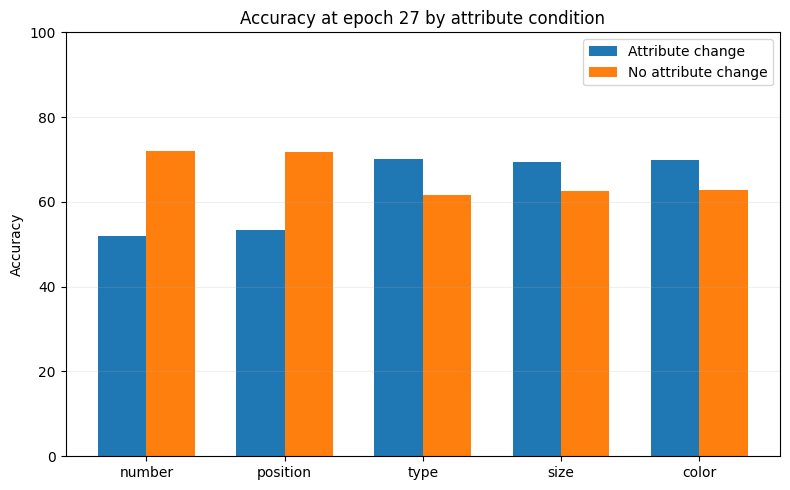

In [150]:
import matplotlib.pyplot as plt
import pandas as pd

df = attribute_final_results  # columns: attribute, attribute_change, no_attribute_change

x = range(len(df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], df['attribute_change'], width, label='Attribute change')
plt.bar([i + width/2 for i in x], df['no_attribute_change'], width, label='No attribute change')

plt.xticks(x, df['attribute'])
plt.ylabel('Accuracy')
plt.title('Accuracy at epoch 27 by attribute condition')
plt.ylim(0, 100)  # adjust if your accuracies are percentages
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

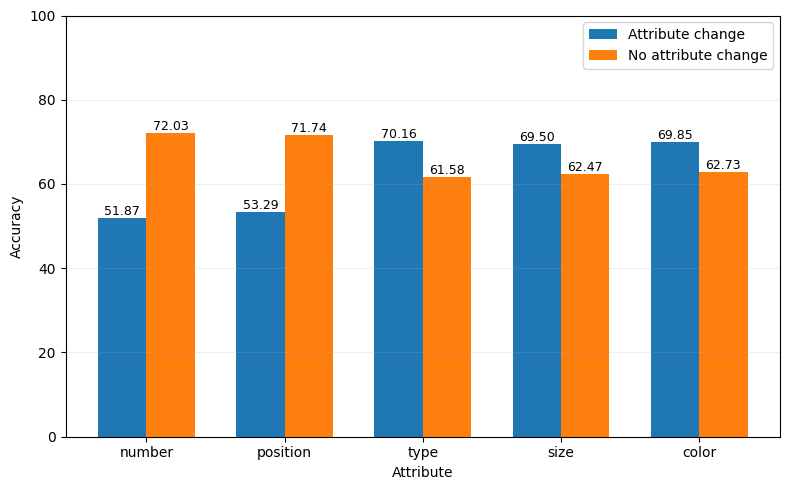

In [155]:
import matplotlib.pyplot as plt
import pandas as pd

df = attribute_final_results  # columns: attribute, attribute_change, no_attribute_change

x = range(len(df))
width = 0.35

plt.figure(figsize=(8, 5))
bars_change = plt.bar([i - width/2 for i in x], df['attribute_change'], width, label='Attribute change')
bars_no_change = plt.bar([i + width/2 for i in x], df['no_attribute_change'], width, label='No attribute change')

plt.xticks(x, df['attribute'])
plt.ylabel('Accuracy')
plt.xlabel('Attribute')
# plt.title('Accuracy by Attribute')
plt.ylim(0, 100)  # adjust if your accuracies are percentages
plt.legend()
plt.grid(axis='y', alpha=0.2)

# Add labels on top of bars
for bars in (bars_change, bars_no_change):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

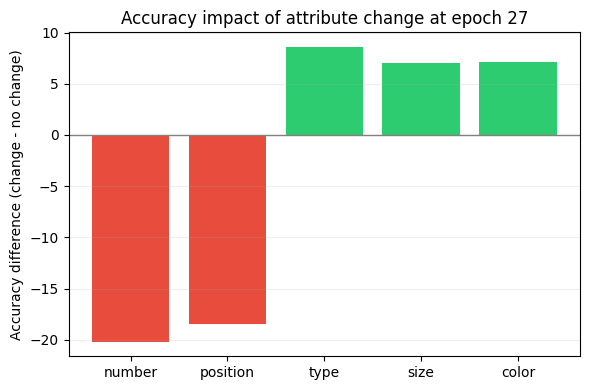

In [151]:
df['delta'] = df['attribute_change'] - df['no_attribute_change']

plt.figure(figsize=(6,4))
plt.bar(df['attribute'], df['delta'], color=['#2ecc71' if d>=0 else '#e74c3c' for d in df['delta']])
plt.axhline(0, color='gray', linewidth=1)
plt.ylabel('Accuracy difference (change - no change)')
plt.title('Accuracy impact of attribute change at epoch 27')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [139]:
attribute_final_results

,attribute,attribute_change,no_attribute_change
0,number,51.87,72.03
1,position,53.29,71.74
2,type,70.16,61.58
3,size,69.50,62.47
4,color,69.85,62.73


In [156]:
import pandas as pd

attributes = ['low', 'medium', 'high']

attribute_final_results = pd.DataFrame(columns=['attribute', 'attribute_change'])
for attribute in attributes:
    pd_rule = pd.read_csv(f'evaluation_results_{attribute}.csv')
    # pd_reverse =  pd.read_csv(f'evaluation_results_non_{attribute}.csv')

    accuracy_attribute_change = round(pd_rule[pd_rule['epoch']== 27]['accuracy'].iloc[0],2)
    # accuracy_no_attribute_change = round(pd_reverse[pd_reverse['epoch']== 27]['accuracy'].iloc[0],2)
    results = {
        'attribute': attribute,
        'attribute_change': accuracy_attribute_change,
        # 'no_attribute_change': accuracy_no_attribute_change
    }
    attribute_final_results.loc[len(attribute_final_results)] = results
    
attribute_final_results.to_csv('attribute_final_results_df.csv')

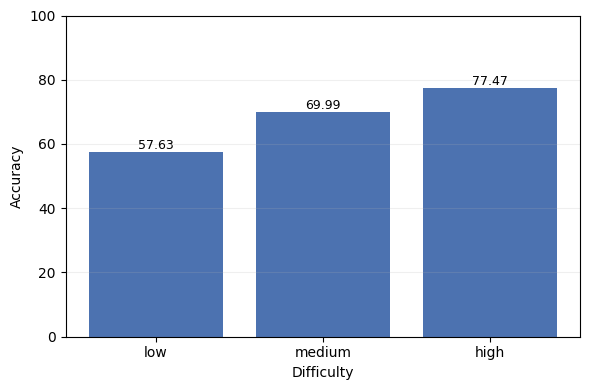

In [159]:
import matplotlib.pyplot as plt
import pandas as pd

df = attribute_final_results  # has columns: attribute, attribute_change

plt.figure(figsize=(6,4))
bars = plt.bar(df['attribute'], df['attribute_change'], color='#4c72b0')

plt.ylabel('Accuracy')
plt.xlabel('Difficulty')
# plt.title('Accuracy at epoch 27 by difficulty level')
plt.ylim(0, 100)  # adjust if needed
plt.grid(axis='y', alpha=0.2)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()